written in colab

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# **Task 1**

In [ ]:
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

In [ ]:
X, y

(array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
# podzial na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    train_size=0.5,
    random_state=0
)

In [ ]:
# drzewo
clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', min_samples_split=5)

In [ ]:
print("Depth:", clf.get_depth())
print("Leaves:", clf.get_n_leaves())
print("Nodes:", clf.tree_.node_count)

Depth: 4
Leaves: 10
Nodes: 19


#### Analyze how different parameters (criterion, splitter, max depth, min samples split) affect the structure, depth, and size of the tree.

In [ ]:
# eksperyment - criterion
criteria = ["gini", "entropy"]

for crit in criteria:

    clf = DecisionTreeClassifier(
        criterion=crit,
        random_state=0
    )

    clf.fit(X_train, y_train)

    print(f"\nCriterion = {crit}")
    print("Depth:", clf.get_depth())
    print("Leaves:", clf.get_n_leaves())
    print("Nodes:", clf.tree_.node_count)
    print("Train acc:", clf.score(X_train, y_train))
    print("Test acc:", clf.score(X_test, y_test))


Criterion = gini
Depth: 7
Leaves: 14
Nodes: 27
Train acc: 1.0
Test acc: 0.9298245614035088

Criterion = entropy
Depth: 5
Leaves: 13
Nodes: 25
Train acc: 1.0
Test acc: 0.9403508771929825


In [ ]:
# eksperyment - splitter
splitters = ["best", "random"]

for split in splitters:

    clf = DecisionTreeClassifier(
        criterion="entropy",
        splitter=split,
        random_state=0
    )

    clf.fit(X_train, y_train)

    print(f"\nSplitter = {split}")
    print("Depth:", clf.get_depth())
    print("Leaves:", clf.get_n_leaves())
    print("Nodes:", clf.tree_.node_count)
    print("Train acc:", clf.score(X_train, y_train))
    print("Test acc:", clf.score(X_test, y_test))


Splitter = best
Depth: 5
Leaves: 13
Nodes: 25
Train acc: 1.0
Test acc: 0.9403508771929825

Splitter = random
Depth: 8
Leaves: 22
Nodes: 43
Train acc: 1.0
Test acc: 0.9263157894736842


In [ ]:
# eksperyment max depth
depths = [1, 2, 3, 5, 10, None]

results = []

for depth in depths:

    clf = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=0
    )

    clf.fit(X_train, y_train)

    results.append([
        str(depth),
        clf.get_depth(),
        clf.get_n_leaves(),
        clf.score(X_train, y_train),
        clf.score(X_test, y_test)
    ])

for row in results:
    print(row)

['1', 1, np.int64(2), 0.9295774647887324, 0.8947368421052632]
['2', 2, np.int64(4), 0.9295774647887324, 0.8947368421052632]
['3', 3, np.int64(7), 0.9788732394366197, 0.9368421052631579]
['5', 5, np.int64(13), 1.0, 0.9403508771929825]
['10', 5, np.int64(13), 1.0, 0.9403508771929825]
['None', 5, np.int64(13), 1.0, 0.9403508771929825]


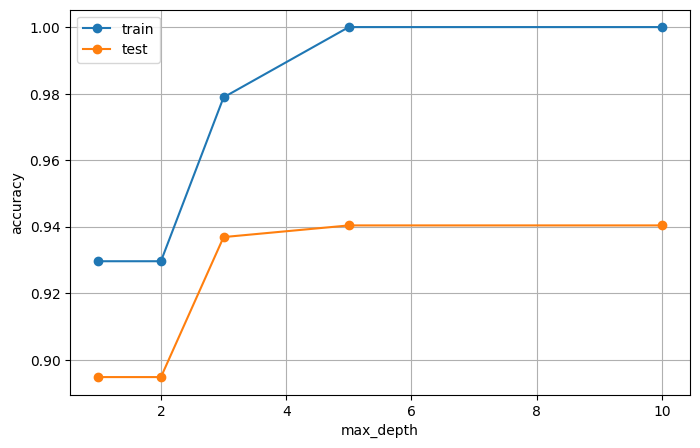

In [ ]:
train_acc = []
test_acc = []

for depth in depths[:-1]:

    clf = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=0
    )

    clf.fit(X_train, y_train)

    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(8,5))
plt.plot(depths[:-1], train_acc, marker="o", label="train")
plt.plot(depths[:-1], test_acc, marker="o", label="test")

plt.xlabel("max_depth")
plt.ylabel("accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# eksperyment - min samples split
splits = [2, 5, 10, 20, 50]

for split in splits:

    clf = DecisionTreeClassifier(
        criterion="entropy",
        min_samples_split=split,
        random_state=0
    )

    clf.fit(X_train, y_train)

    print(f"\nmin_samples_split = {split}")
    print("Depth:", clf.get_depth())
    print("Leaves:", clf.get_n_leaves())
    print("Nodes:", clf.tree_.node_count)
    print("Train acc:", clf.score(X_train, y_train))
    print("Test acc:", clf.score(X_test, y_test))


min_samples_split = 2
Depth: 5
Leaves: 13
Nodes: 25
Train acc: 1.0
Test acc: 0.9403508771929825

min_samples_split = 5
Depth: 4
Leaves: 10
Nodes: 19
Train acc: 0.9894366197183099
Test acc: 0.9228070175438596

min_samples_split = 10
Depth: 4
Leaves: 10
Nodes: 19
Train acc: 0.9894366197183099
Test acc: 0.9228070175438596

min_samples_split = 20
Depth: 3
Leaves: 6
Nodes: 11
Train acc: 0.9683098591549296
Test acc: 0.9368421052631579

min_samples_split = 50
Depth: 3
Leaves: 5
Nodes: 9
Train acc: 0.9295774647887324
Test acc: 0.8912280701754386


#### **(b) Draw a tree**

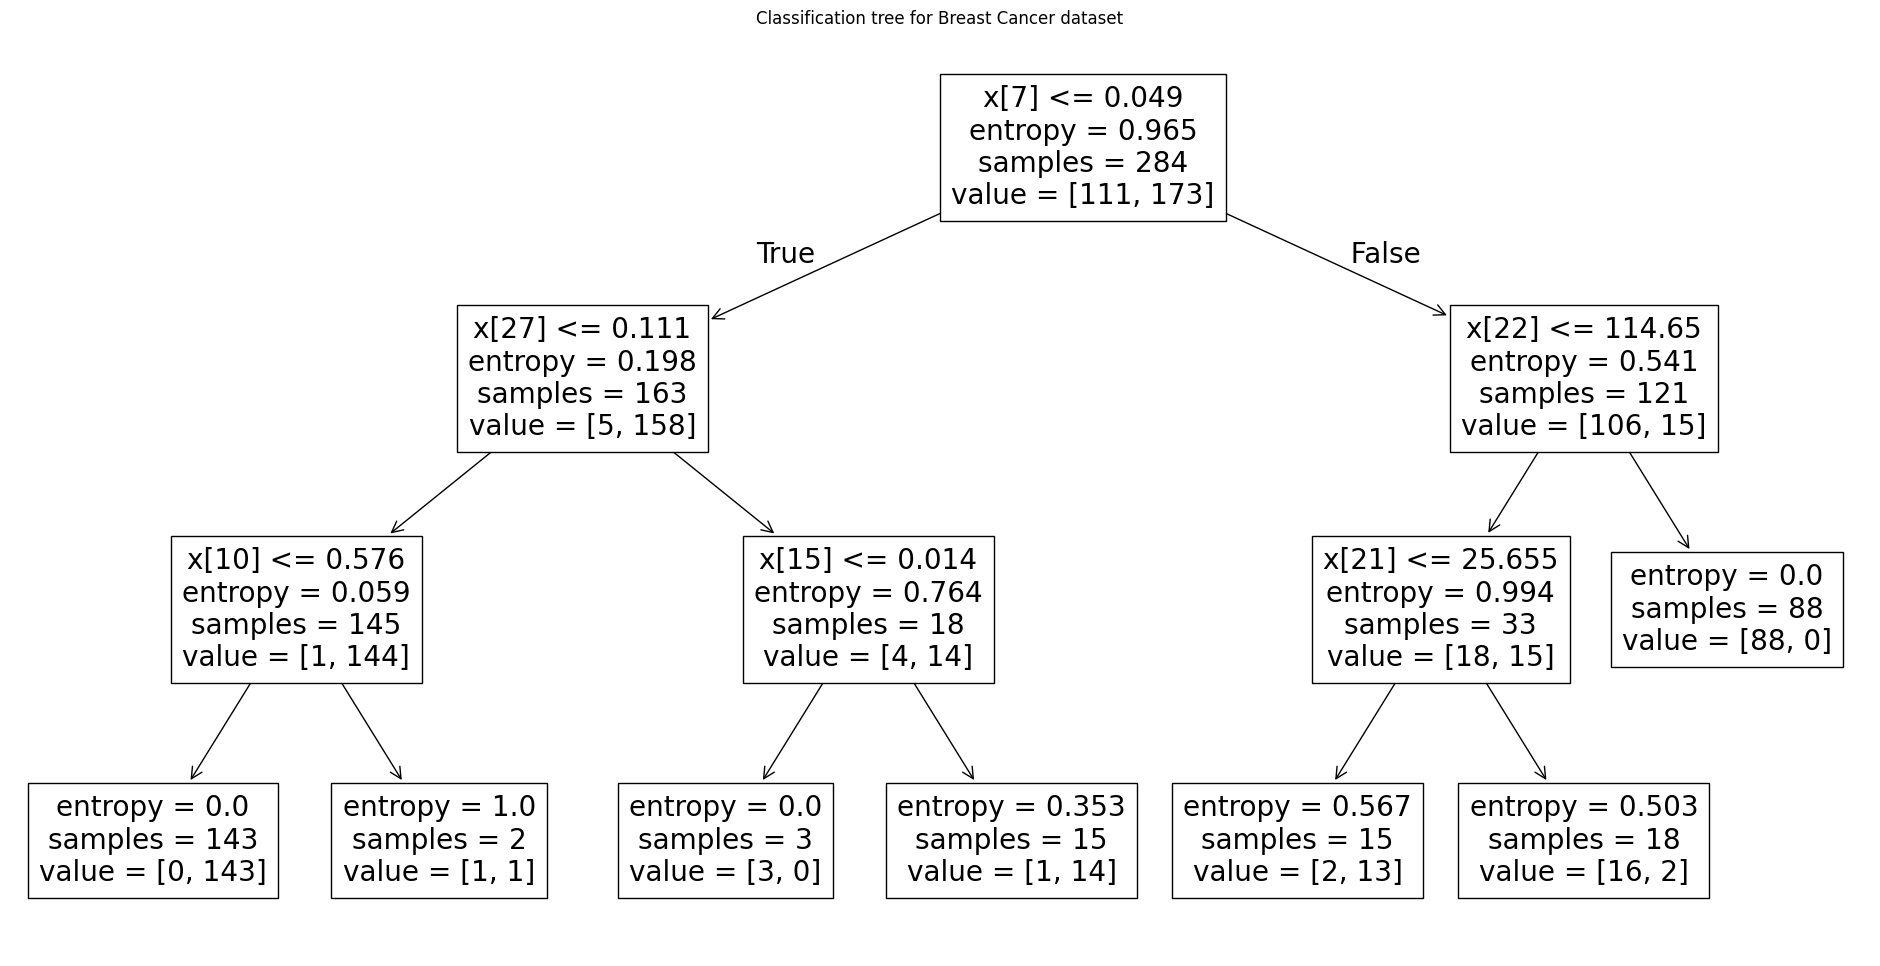

In [ ]:
clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=0
)

clf.fit(X_train, y_train)

plt.figure(figsize=(24, 12))
plot_tree(clf)
plt.title("Classification tree for Breast Cancer dataset")
plt.show()

Interpretation:<br>
The root node splits the data using feature x[7] with threshold 0.049. This is the most important split because it divides all 284 training observations into two large groups. Observations satisfying x[7] ≤ 0.049 are sent to the left branch, while the remaining observations are sent to the right branch.

The left child node contains 163 samples with class distribution [5, 158], which means it is dominated by class 1. The entropy decreases from 0.965 to 0.198, indicating that this split creates a much more homogeneous group. This branch is further divided using feature x[27] ≤ 0.111.

The right child node contains 121 samples with class distribution [106, 15], which means it is dominated by class 0. The entropy decreases to 0.541, showing that the observations are more concentrated in a single class than in the root node. This branch is further split using feature x[22] ≤ 114.65.

Overall, the first split already separates most benign and malignant cases, while the following splits refine the classification by creating increasingly pure subsets of observations.

#### **(c) Prune the default tree using the cost-complexity criterion. Compare the pruned and unpruned trees in terms of size and predictive performance.**

1. Uczymy domyslne drzewo
2. Znajdujemy mozliwe wartosci ccc_alpha
3. Wybieramy najlepsze
4. Uczymy przyciete drzewo
5. Porownujemy: depth, nodes, leave

In [26]:
# drzewo nieprzyciete
unpruned_tree = DecisionTreeClassifier(random_state=0)
unpruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [27]:
# rozmiary drzewa nieprzycietego
print("Depth:", unpruned_tree.get_depth())
print("Leaves:", unpruned_tree.get_n_leaves())
print("Nodes:", unpruned_tree.tree_.node_count)

print("Train accuracy:", unpruned_tree.score(X_train, y_train))
print("Test accuracy:", unpruned_tree.score(X_test, y_test))

Depth: 7
Leaves: 14
Nodes: 27
Train accuracy: 1.0
Test accuracy: 0.9298245614035088


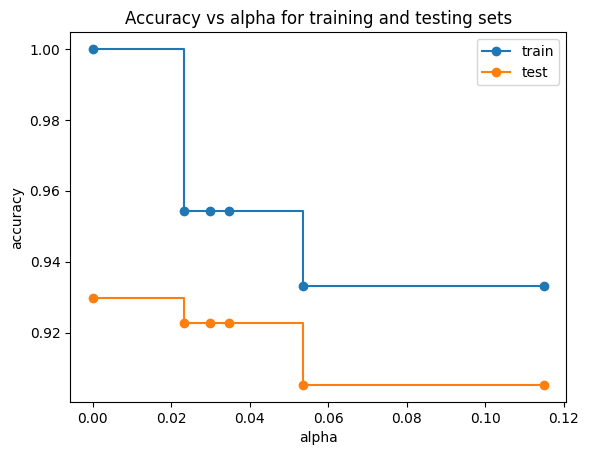

In [28]:
# cost-complexity pruning
# zamiast minimalizowac tylko blad: Error(T)
# minimalizujemy: Error(T) + α · |T|,
# gdzie:
# - α - kara za wielkosc drzewa
# - |T| - liczba lisci

path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fix, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas[:-1], train_scores[:-1], marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[:-1], test_scores[:-1], marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [32]:
# best alpha
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
print(best_alpha)

# uczymy przyciete drzewo
pruned_tree = DecisionTreeClassifier(
    random_state=0,
    ccp_alpha=best_alpha
)

pruned_tree.fit(X_train, y_train)

# comparison unpruned & pruned
print("UNPRUNED")
print("Depth:", unpruned_tree.get_depth())
print("Leaves:", unpruned_tree.get_n_leaves())
print("Nodes:", unpruned_tree.tree_.node_count)
print("Train acc:", unpruned_tree.score(X_train, y_train))
print("Test acc:", unpruned_tree.score(X_test, y_test))

print()

print("PRUNED")
print("Depth:", pruned_tree.get_depth())
print("Leaves:", pruned_tree.get_n_leaves())
print("Nodes:", pruned_tree.tree_.node_count)
print("Train acc:", pruned_tree.score(X_train, y_train))
print("Test acc:", pruned_tree.score(X_test, y_test))

0.0
UNPRUNED
Depth: 7
Leaves: 14
Nodes: 27
Train acc: 1.0
Test acc: 0.9298245614035088

PRUNED
Depth: 7
Leaves: 14
Nodes: 27
Train acc: 1.0
Test acc: 0.9298245614035088


# **Task 2**

In [35]:
# single tree for comparison
single_tree = DecisionTreeClassifier(random_state=0)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)

print("Single tree accuracy:", accuracy_score(y_test, y_pred_tree))
print("Single tree balanced accuracy:", balanced_accuracy_score(y_test, y_pred_tree))

Single tree accuracy: 0.9298245614035088
Single tree balanced accuracy: 0.9210880327163151


In [48]:
# bagging classifier
class ImpBaggingClassifier:
    def __init__(self, n_estimators=50, random_state=0):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        np.random.seed(self.random_state)

        n_samples = X.shape[0]
        self.models = []

        for i in range(self.n_estimators):
            # bootstrap sample: losowanie indeksów z powtórzeniami
            indices = np.random.choice(
                n_samples,
                size=n_samples,
                replace=True
            )

            X_bootstrap = X[indices]
            y_bootstrap = y[indices]

            tree = DecisionTreeClassifier(
                random_state=self.random_state + i
            )

            tree.fit(X_bootstrap, y_bootstrap)

            self.models.append(tree)

        return self

    def predict(self, X):
        # predictions shape: n_estimators x n_observations
        predictions = np.array([
            model.predict(X)
            for model in self.models
        ])

        # majority voting
        final_predictions = []

        for j in range(X.shape[0]):
            votes = predictions[:, j]
            counts = np.bincount(votes)
            final_predictions.append(np.argmax(counts))

        return np.array(final_predictions)

In [49]:
bagging = ImpBaggingClassifier(
    n_estimators=50,
    random_state=0
)

bagging.fit(X_train, y_train)

y_pred_bagging = bagging.predict(X_test)

print("Bagging accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Bagging balanced accuracy:", balanced_accuracy_score(y_test, y_pred_bagging))

Bagging accuracy: 0.9438596491228071
Bagging balanced accuracy: 0.9319575979337065


In [50]:
# comparison
comparison = {
    "model": ["Single tree", "Bagging"],
    "accuracy": [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_bagging)
    ],
    "balanced_accuracy": [
        balanced_accuracy_score(y_test, y_pred_tree),
        balanced_accuracy_score(y_test, y_pred_bagging)
    ]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)
comparison_df

,model,accuracy,balanced_accuracy
0,Single tree,0.929825,0.921088
1,Bagging,0.943860,0.931958


Compared with a single decision tree, bagging usually gives more stable predictions. A single tree is sensitive to small changes in the training data, because a slightly different dataset can produce a very different tree. Bagging reduces this instability by averaging the predictions of many trees trained on different bootstrap samples.

As a result, bagging may improve predictive performance and reduce overfitting. The improvement is especially visible for high-variance models such as decision trees.

# **Task 3**

In [41]:
data_spam = pd.read_csv("Spam.csv")
data_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_hash,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [45]:
X_spam = data_spam.drop(columns="spam")
y_spam = data_spam["spam"]

In [52]:
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam,
    y_spam,
    test_size=0.3,
    train_size=0.7,
    random_state=42,
)

In [53]:
models = {
    "Single tree": DecisionTreeClassifier(random_state=0),
    "Bagging": BaggingClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0)
}

In [54]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "dataset": "spam.csv",
        "method": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,dataset,method,accuracy,balanced_accuracy,precision,recall,f1_score
0,spam.csv,Single tree,0.929825,0.921088,0.940860,0.951087,0.945946
1,spam.csv,Bagging,0.947368,0.939141,0.951872,0.967391,0.959569
2,spam.csv,Random Forest,0.954386,0.949042,0.962162,0.967391,0.964770


The three methods were compared on the spam dataset using the same train/test split.

The single decision tree is the simplest method, but it can be unstable and sensitive to small changes in the training data. Bagging improves stability by training many trees on bootstrap samples and combining their predictions by voting.

Random Forest usually performs better than a single tree and can also outperform bagging, because it introduces additional randomness by selecting random subsets of features when splitting nodes. This reduces correlation between trees and often improves generalization.

Overall, ensemble methods such as Bagging and Random Forest are expected to be more stable and usually achieve better predictive performance than a single decision tree.